### RaschPy anchor calibration worked example

Anchor calibration places a new calibration on the same scale as an external reference, using a subset of 'anchor' items to compute a translation constant that shifts the new items onto the same scale as the anchors. RaschPy supports two distinct anchoring workflows:

1. **Item-bank anchoring** (`SLM`, `RSM`, `PCM`) — anchor a new item calibration onto a bank of previously-calibrated item locations (e.g. for vertical scaling, or linking test forms).
2. **Rater anchoring** (`MFRM`) — anchor a set of raters' severities to a common zero point (e.g. a set of 'gold standard' raters), so scores from different rating occasions are comparable.

Both automatically down-weight or exclude outlier anchor elements through an optional purification process, so a handful of stale or misbehaving anchors do not distort the shift applied to the rest of the scale.

#### Item-bank anchoring (SLM / RSM / PCM)

In [1]:
import raschpy as rp

Simulate a data set and calibrate as usual.

In [2]:
sim = rp.SLM_Sim(no_of_items=30, no_of_persons=500, item_range=3, seed=42)
slm = rp.SLM(sim)
slm.calibrate()

Let us suppose that the first 10 of these items are drawn from an external item bank, calibrated previously on a large reference sample. We use the generating item locations from the simulations as the item bank locations here, except for the location of `Item_3`, which we corrupt by 1 logit1, to simulate a stale or misbehaving anchor:

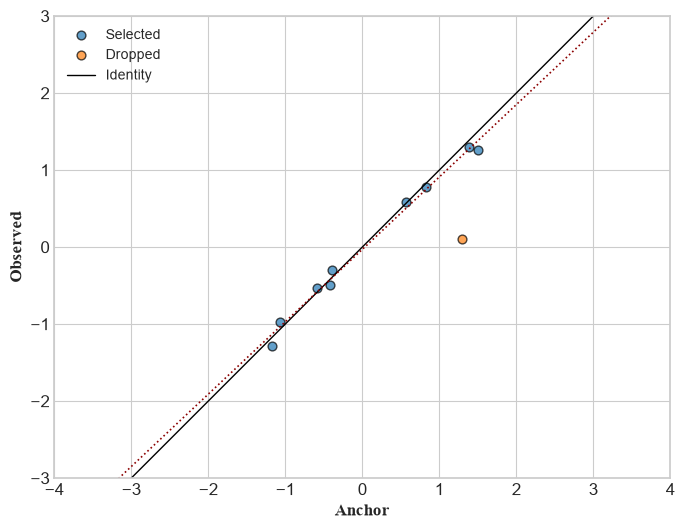

In [3]:
bank_items = list(sim.items.index[:10])
bank_locations = sim.items.loc[bank_items].copy()
bank_locations['Item_3'] += 1   # deliberately corrupted anchor value

slm.calibrate_anchor(bank_locations)

`anchor_summary` gives a one-line overview: how many anchors were supplied/common/selected/dropped, the correlation and SD ratio before and after trimming, and the translation constant applied.

In [4]:
slm.anchor_summary

Anchors supplied        10.000000
Anchors common          10.000000
Anchors selected         9.000000
Anchors dropped          1.000000
Original corr            0.930514
Original SD ratio        0.875808
Final corr               0.995230
Final SD ratio           0.944487
Translation constant     0.034384
Name: Anchor calibration, dtype: float64

`anchor_selection` gives the full per-anchor-item diagnostics. `Item_3` — the deliberately corrupted item — should be the only one excluded (`Selected=False`), and the correlation should improve substantially between the 'before trimming' and 'after trimming' figures in `anchor_summary` above.

In [5]:
slm.anchor_selection

,Anchor,Observed,Deviation,Robust z,Selected
Item_1,-0.396903,-0.302131,0.094772,1.109659,True
Item_2,-1.063016,-0.966787,0.096229,1.120276,True
Item_3,1.299462,0.099276,-1.200186,-8.329082,False
Item_4,-1.166415,-1.285290,-0.118875,-0.447578,True
Item_5,-0.419271,-0.487373,-0.068102,-0.077505,True
Item_6,1.388856,1.298947,-0.089909,-0.236456,True
Item_7,1.501684,1.254808,-0.246876,-1.380562,True
Item_8,0.821219,0.774384,-0.046835,0.077505,True
Item_9,-0.583654,-0.537606,0.046047,0.754511,True
Item_10,0.563973,0.588066,0.024093,0.594489,True


`anchor_items` holds the item locations shifted onto the bank's scale. Diagnostics are plotted automatically by default (`plot=True`), accessible as `slm.anchor_plot`, or callable manually via `plot_anchor_selection()` against any `anchor_selection`-shaped table:

In [6]:
slm.anchor_items.head()

Item_1   -0.396903
Item_2   -1.063016
Item_3    1.299462
Item_4   -1.166415
Item_5   -0.419271
dtype: float64

`calibrate_anchor()` is available identically on `RSM` and `PCM` — e.g. `rsm.calibrate_anchor(bank_locations)`, `pcm.calibrate_anchor(bank_locations)` — with the same `anchor_items` / `anchor_summary` / `anchor_selection` attributes.

#### Checking threshold/category structure (RSM / PCM)

Item-bank anchoring above is a translation only: `anchor_items` shifts the item-location scale onto the bank, but the category/threshold structure is assumed to be shared with the bank and is left untouched. `anchor_thresholds=` allows you to check that assumption for both `RSM` and `PCM`.

**RSM** has a single Rasch-Andrich threshold vector shared across every item (`self.thresholds`). `calibrate_anchor()` does not create a shifted copy of it — a location shift leaves the threshold structure untouched, so there is nothing to anchor. However, `calibrate_anchor()` offers an optional check to validate whether the threshold structure remains unchanged between the anchor values and the observed data. By passing the anchor threshold values using `anchor_thresholds=`, a likelihood-ratio test runs that comparing this dataset's own thresholds against the ones you supplied (item locations held fixed at `anchor_items`). The result is stored in `anchor_threshold_test`, with a `UserWarning` if `Flagged=True` — a signal that the rating-scale category structure may not really be shared, which would undermine a translation-only equating assumption and threaten the validity of the anchoring process.

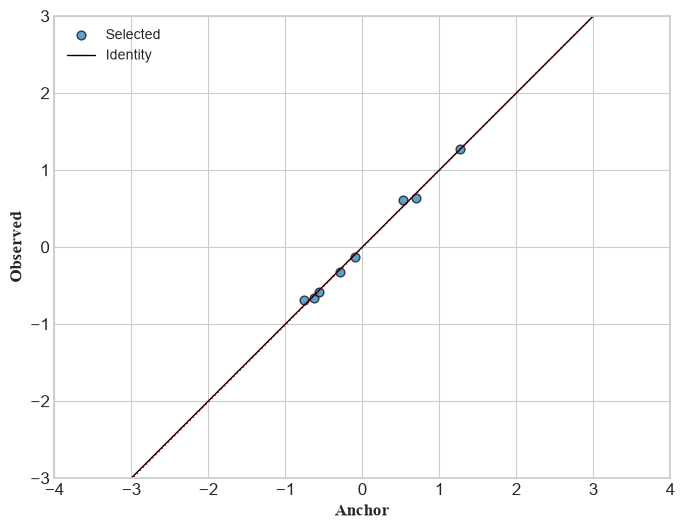

LL_estimated   -19248.177336
LL_given       -19248.177336
LR                       0.0
df                         3
p                        1.0
Flagged                False
Name: Anchor threshold structure test, dtype: object

In [7]:
sim_rsm = rp.RSM_Sim(no_of_items=20, no_of_persons=1000, max_score=4, seed=7)
rsm = rp.RSM(sim_rsm)
rsm.calibrate()

bank_items_rsm = list(sim_rsm.items.index[:8])
bank_locations_rsm = sim_rsm.items.loc[bank_items_rsm]
bank_thresholds = rsm.thresholds.copy()   # here, the bank's own (genuinely compatible) threshold vector

rsm.calibrate_anchor(bank_locations_rsm, anchor_thresholds=bank_thresholds)
rsm.anchor_threshold_test

In [8]:
rsm.anchor_category_width_test

,Estimate,Given,Difference,SE,z,p,p_corrected,Flagged
Category,,,,,,,,
1,0.286710,0.286710,0.0,0.051113,0.0,1.0,1.0,False
2,0.452628,0.452628,0.0,0.052478,0.0,1.0,1.0,False
3,0.232776,0.232776,0.0,0.053874,0.0,1.0,1.0,False


Identical thresholds are not flagged (`LR=0`, `p=1`). Now suppose the bank's category structure genuinely differs — e.g. its first category is much narrower than this dataset's own:

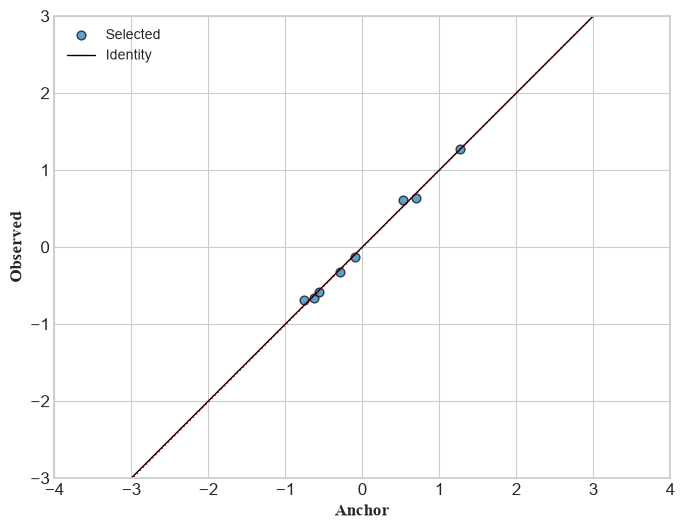

/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_51634/1394094638.py:4: UserWarning: anchor_thresholds differs substantially from this dataset's own estimated threshold structure (LR test; see anchor_threshold_test). The rating-scale category structure may not actually be shared with the anchor source — translation-only equating via anchor_items assumes it is.
  rsm.calibrate_anchor(bank_locations_rsm, anchor_thresholds=bank_thresholds_corrupted)
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_51634/1394094638.py:4: UserWarning: anchor_thresholds differs substantially from this dataset's own estimated category widths at [1] (per-category Wald test; see anchor_category_width_test). The rating-scale category structure may not actually be shared with the anchor source at these categories — translation-only equating via anchor_items assumes it is.
  rsm.calibrate_anchor(bank_locations_rsm, anchor_thresholds=bank_thresholds_corrupted)


LL_estimated   -19248.177336
LL_given       -22384.844216
LR               6273.333761
df                         3
p                        0.0
Flagged                 True
Name: Anchor threshold structure test, dtype: object

In [9]:
bank_thresholds_corrupted = bank_thresholds.copy()
bank_thresholds_corrupted.iloc[0] += 2.5   # deliberately distort one category width

rsm.calibrate_anchor(bank_locations_rsm, anchor_thresholds=bank_thresholds_corrupted)
rsm.anchor_threshold_test

Alongside the omnibus test, `calibrate_anchor()` also runs a per-category check: it compares category widths (differences between adjacent  thresholds) rather than the raw threshold values themselves, one width at a time, via a Wald z-test against this dataset's own bootstrap category-width SEs (`cat_width_se` — auto-computed if not already available). The result is `anchor_category_width_test`.

This distinction matters for the same reason it does in `dif_test`'s category-width (DCF) test: raw threshold values are cumulative sums of category widths, so a genuine difference in one category's width shows up in every threshold after it too — testing raw values directly would smear one true effect across several categories, rather than localising it to the one that actually differs. The corrupted example below only changes the first category's width, with `anchor_category_width_test` correctly flagging only Category 1 while leaving the others untouched, unlike a raw-location comparison, which might flag every category from the point of distortion onwards.

(The omnibus test above doesn't have this problem itself, for a different reason: it compares model fit via a full likelihood refit rather than raw parameter values directly; refitting freely re-estimates person locations, which absorbs any *uniform* shift in the threshold vector. It therefore only detects genuine differences in the shape of the threshold structure, never a harmless difference in arbitrary centring conventions. The per-category test fulfils a different role: not just determining *whether* the threshold structure differs, but *where* it differs.

In [10]:
rsm.anchor_category_width_test

,Estimate,Given,Difference,SE,z,p,p_corrected,Flagged
Category,,,,,,,,
1,0.286710,-2.213290,2.5,0.051113,48.910762,0.0,0.0,True
2,0.452628,0.452628,0.0,0.052478,0.000000,1.0,1.0,False
3,0.232776,0.232776,0.0,0.053874,0.000000,1.0,1.0,False


**PCM** has independent thresholds per item rather than one shared vector, so the check is per-item too: pass `anchor_thresholds={item_name: offsets, ...}` (need not include every anchor item) with `threshold_check='per_item'|'aggregate'|'both'|'none'` (default `'both'`). `'per_item'` runs one independent LR test per supplied item, BH/Bonferroni-corrected across items (`correction=`); `'aggregate'` runs one combined test swapping every supplied item's thresholds in simultaneously. Results are stored in `anchor_threshold_test` (per-item table) and `anchor_threshold_test_aggregate` (single combined test).

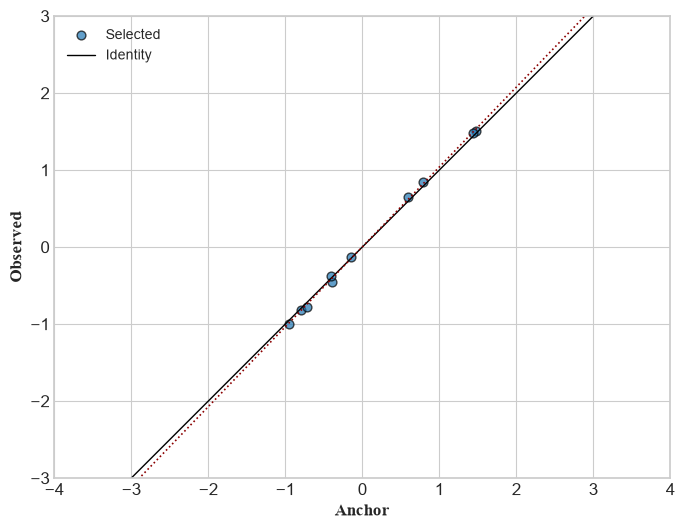

,LL_estimated,LL_given,LR,df,p,p_corrected,Flagged
Item_1,-15117.792845,-15117.792845,0.0,3.0,1.0,1.0,False
Item_2,-15117.792845,-15117.792845,0.0,3.0,1.0,1.0,False
Item_3,-15117.792845,-15117.792845,0.0,3.0,1.0,1.0,False
Item_4,-15117.792845,-15117.792845,0.0,3.0,1.0,1.0,False
Item_5,-15117.792845,-15117.792845,0.0,3.0,1.0,1.0,False
Item_6,-15117.792845,-15117.792845,0.0,3.0,1.0,1.0,False
Item_7,-15117.792845,-15117.792845,0.0,3.0,1.0,1.0,False
Item_8,-15117.792845,-15117.792845,0.0,3.0,1.0,1.0,False
Item_9,-15117.792845,-15117.792845,0.0,3.0,1.0,1.0,False
Item_10,-15117.792845,-15117.792845,0.0,3.0,1.0,1.0,False


In [11]:
sim_pcm = rp.PCM_Sim(no_of_items=15, no_of_persons=1000, max_score_vector=[4] * 15, category_base=1.5, seed=7)
pcm = rp.PCM(sim_pcm)
pcm.calibrate()

bank_items_pcm = list(sim_pcm.items.index[:10])
bank_locations_pcm = sim_pcm.items.loc[bank_items_pcm]
bank_thresholds_pcm = {item: pcm.thresholds.loc[item].dropna().values for item in bank_items_pcm}

pcm.calibrate_anchor(bank_locations_pcm, anchor_thresholds=bank_thresholds_pcm)
pcm.anchor_threshold_test

In [12]:
pcm.anchor_threshold_test_aggregate

LL_estimated   -15117.792845
LL_given       -15117.792845
LR                       0.0
df                        30
p                        1.0
Flagged                False
Name: Anchor threshold structure test (aggregate), dtype: object

As with RSM, distorting one item's supplied thresholds correctly localises to just that item in the per-item table, while still showing up in the combined aggregate test:

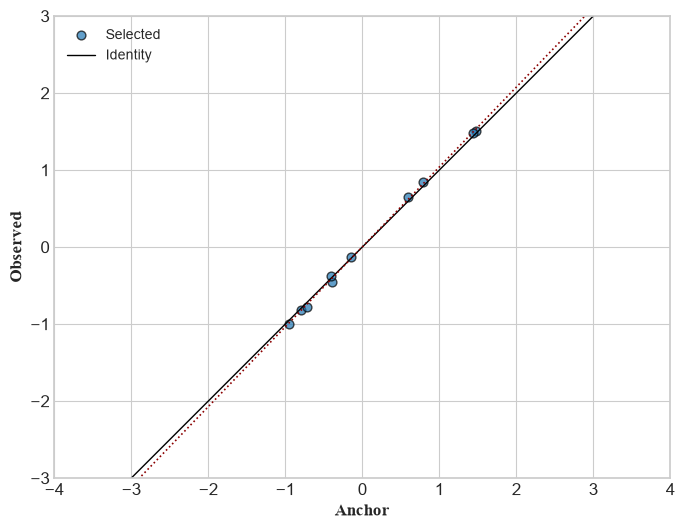

/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_51634/1872314217.py:5: UserWarning: anchor_thresholds differs substantially from this dataset's own estimated threshold structure for ['Item_1'] (per-item LR test; see anchor_threshold_test). The rating-scale category structure may not actually be shared with the anchor source for these items — translation-only equating via anchor_items assumes it is.
  pcm.calibrate_anchor(bank_locations_pcm, anchor_thresholds=bank_thresholds_pcm_corrupted)
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_51634/1872314217.py:5: UserWarning: anchor_thresholds differs substantially from this dataset's own estimated threshold structure, combined across all supplied items (aggregate LR test; see anchor_threshold_test_aggregate). The rating-scale category structure may not actually be shared with the anchor source — translation-only equating via anchor_items assumes it is.
  pcm.calibrate_anchor(bank_locations_pcm, anchor_thresholds=bank_

,LL_estimated,LL_given,LR,df,p,p_corrected,Flagged
Item_1,-15117.792845,-15467.668943,699.752195,3.0,2.375598e-151,2.375598e-150,True
Item_2,-15117.792845,-15117.792845,0.000000,3.0,1.000000e+00,1.000000e+00,False
Item_3,-15117.792845,-15117.792845,0.000000,3.0,1.000000e+00,1.000000e+00,False
Item_4,-15117.792845,-15117.792845,0.000000,3.0,1.000000e+00,1.000000e+00,False
Item_5,-15117.792845,-15117.792845,0.000000,3.0,1.000000e+00,1.000000e+00,False
Item_6,-15117.792845,-15117.792845,0.000000,3.0,1.000000e+00,1.000000e+00,False
Item_7,-15117.792845,-15117.792845,0.000000,3.0,1.000000e+00,1.000000e+00,False
Item_8,-15117.792845,-15117.792845,0.000000,3.0,1.000000e+00,1.000000e+00,False
Item_9,-15117.792845,-15117.792845,0.000000,3.0,1.000000e+00,1.000000e+00,False
Item_10,-15117.792845,-15117.792845,0.000000,3.0,1.000000e+00,1.000000e+00,False


In [13]:
bank_thresholds_pcm_corrupted = dict(bank_thresholds_pcm)
bank_thresholds_pcm_corrupted['Item_1'] = bank_thresholds_pcm['Item_1'].copy()
bank_thresholds_pcm_corrupted['Item_1'][0] += 2.5   # deliberately distort one item's category structure

pcm.calibrate_anchor(bank_locations_pcm, anchor_thresholds=bank_thresholds_pcm_corrupted)
pcm.anchor_threshold_test

In [14]:
pcm.anchor_threshold_test_aggregate

LL_estimated   -15117.792845
LL_given       -15467.668943
LR                699.752195
df                        30
p                        0.0
Flagged                 True
Name: Anchor threshold structure test (aggregate), dtype: object

#### Rater anchoring (MFRM)

Simulate a rating design with 6 raters. Rater_4 is deliberately made much more severe than the others (+2.5 logits), so does not really belong as part of the 'gold standard' anchor set.

In [15]:
sim_mfrm = rp.MFRM_Sim_Global(no_of_items=10, no_of_persons=300, no_of_raters=6, max_score=4,
                              manual_raters={'Rater_1': 0.0, 'Rater_2': 0.1, 'Rater_3': -0.1,
                                             'Rater_4': 2.5, 'Rater_5': 0.5, 'Rater_6': -0.5},
                              seed=1)
mfrm = rp.MFRM(sim_mfrm)
mfrm.calibrate_global()

**Checking anchor rater homogeneity before anchoring**

Anchoring only constrains the *mean* severity of the chosen anchor set to zero — on its own, it does not check whether that mean is a stable, shared reference point or an artefact of averaging over raters who exhibit different behaviours. Suppose we intend to anchor to Raters 1-4; `check_anchor_homogeneity()` tests whether that proposed anchor set actually agrees with itself first:

In [16]:
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.check_anchor_homogeneity(model='global', anchors=anchors, no_of_samples=300)

mfrm.anchor_homogeneity_test        # omnibus Cochran's Q test

/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_51634/2118129591.py:2: UserWarning: Anchor rater(s) ['Rater_2', 'Rater_4'] do not appear homogeneous with the rest of the anchor set (cochran test; see anchor_homogeneity_per_rater). The anchor-defined zero point may be unstable — consider revising the anchor set.
  mfrm.check_anchor_homogeneity(model='global', anchors=anchors, no_of_samples=300)


Q                            2297.771817
df                                     3
p                                    0.0
Flagged                             True
N_dropped_for_homogeneity              2
Name: Anchor homogeneity test, dtype: object

In [17]:
mfrm.anchor_homogeneity_per_rater    # per-rater severity, SE, z, p, Flagged

,Facet effect,SE,z,p,Flagged
Rater_1,-0.430544,0.028035,1.466996,0.142377,False
Rater_2,-0.240719,0.02859,5.392673,0.0,True
Rater_3,-0.515849,0.029056,-1.520394,0.128412,False
Rater_4,2.029248,0.048377,44.896647,0.0,True


Rater_4 — the deliberately severe rater — is correctly flagged (sequential exclusion may also flag a second rater whose apparent position shifts once the clearest outlier is set aside; this is expected, not a bug). Given this warning, we'd revise the anchor set (e.g. drop Rater_4) before relying on it. For this walkthrough, we will proceed anyway to see what anchoring against the flawed set looks like:

In [18]:
mfrm.calibrate_global_anchor(anchors)
mfrm.anchor_raters_global    # anchored rater severities

Rater_1   -0.641078
Rater_2   -0.451253
Rater_3   -0.726383
Rater_4    1.818714
Rater_5   -0.155016
Rater_6   -1.108189
dtype: float64

Compare against the unanchored severities — note that the whole scale has shifted so that the anchor set's mean (including the outlier) sits at zero, which is exactly the instability the homogeneity check warned about:

In [19]:
mfrm.raters_global

Rater_1   -0.430544
Rater_2   -0.240719
Rater_3   -0.515849
Rater_4    2.029248
Rater_5    0.055518
Rater_6   -0.897655
dtype: float64

The same `calibrate_anchor(model, anchors)` / `check_anchor_homogeneity(model, anchors)` pattern works identically for the other four MFRM rater parameterisations (`'items'`, `'thresholds'`, `'bivector'`, `'matrix'`), and there are also per-model convenience aliases (e.g. `calibrate_items_anchor(anchors)`, `calibrate_matrix_anchor(anchors)`).